# Perfilamento dinamico de risco - clustering

Objetivo: identificar perfis recorrentes de vitimas e horarios de CVLI usando K-means e K-medoids.

Restricoes definidas para esta etapa:

- nao usar `ESCOLARIDADE VITIMA`;
- nao usar `OCUPACAO VITIMA`;
- nao usar `CIDADE DO FATO`;
- nao usar `BAIRRO DO FATO`.

Observacao: sem cidade/bairro, os grupos representam personas por perfil e horario, nao mapa regional.

## 1. Setup

In [1]:
from pathlib import Path
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, pairwise_distances, silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA_PATH = Path('..') / 'data' / 'raw' / 'cvli_microdados.csv'

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid', palette='viridis')

## 2. Carga e limpeza

In [2]:
raw = pd.read_csv(DATA_PATH)
df = raw.copy()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'NI': pd.NA, 'nan': pd.NA, '': pd.NA})

df['data_fato'] = pd.to_datetime(df['DATA DO FATO'], format='%d/%m/%Y', errors='coerce')
hora = pd.to_datetime(df['HORA DO FATO'], format='%H:%M', errors='coerce')
df['hora'] = hora.dt.hour
df['idade'] = pd.to_numeric(df['IDADE DA VITIMA'], errors='coerce')

df['dia_semana_num'] = df['data_fato'].dt.dayofweek
df['dia_semana'] = df['dia_semana_num'].map({
    0: 'Segunda', 1: 'Terca', 2: 'Quarta', 3: 'Quinta',
    4: 'Sexta', 5: 'Sabado', 6: 'Domingo'
})
df['fim_de_semana'] = df['dia_semana_num'].isin([5, 6])

df['periodo_dia'] = pd.cut(
    df['hora'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Madrugada (0-5)', 'Manha (6-11)', 'Tarde (12-17)', 'Noite (18-23)']
)

df['faixa_etaria'] = pd.cut(
    df['idade'],
    bins=[-1, 11, 17, 24, 29, 39, 59, np.inf],
    labels=['0-11', '12-17', '18-24', '25-29', '30-39', '40-59', '60+']
)

df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)
df['fim_de_semana_num'] = df['fim_de_semana'].astype(int)

print(f'Registros brutos: {len(raw):,}'.replace(',', '.'))
print(f'Registros com idade ausente: {df['idade'].isna().sum()}')
print(f'Registros com hora ausente: {df['hora'].isna().sum()}')

Registros brutos: 21.217
Registros com idade ausente: 448
Registros com hora ausente: 0


/tmp/ipykernel_407218/1897253343.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [3]:
def sem_acento(texto):
    texto = '' if pd.isna(texto) else str(texto)
    texto = unicodedata.normalize('NFKD', texto)
    return texto.encode('ascii', 'ignore').decode('ascii').lower()

def agrupar_instrumento(valor):
    if pd.isna(valor):
        return 'Nao informado'
    valor = str(valor).upper()
    if 'PAF' in valor:
        return 'Arma de fogo'
    if 'BRANCA' in valor:
        return 'Arma branca'
    if 'ESPANCAMENTO' in valor:
        return 'Espancamento'
    return 'Outros'

def agrupar_local(valor):
    if pd.isna(valor):
        return 'Nao informado'
    valor = sem_acento(valor)
    if 'casa' in valor or 'resid' in valor:
        if 'proximo' in valor or 'porta' in valor or 'imedia' in valor:
            return 'Entorno de casa'
        return 'Ambiente interno'
    if 'via' in valor or 'public' in valor:
        return 'Espaco publico'
    if 'veget' in valor or 'terreno' in valor or 'rural' in valor or 'barragem' in valor:
        return 'Area externa/isolada'
    return 'Outros'

df['grupo_instrumento'] = df['INSTRUMENTO UTILIZADO'].map(agrupar_instrumento)
df['grupo_local'] = df['LOCAL DO FATO'].map(agrupar_local)

display(df[['idade', 'faixa_etaria', 'SEXO DA VITIMA', 'COR/RACA DA VITIMA', 'hora', 'periodo_dia', 'dia_semana', 'grupo_local']].head())

,idade,faixa_etaria,SEXO DA VITIMA,COR/RACA DA VITIMA,hora,periodo_dia,dia_semana,grupo_local
0,24.0,18-24,Masculino,NaN,12,Tarde (12-17),Terca,Outros
1,51.0,40-59,Masculino,Parda,13,Tarde (12-17),Terca,Entorno de casa
2,24.0,18-24,Masculino,Amarela,13,Tarde (12-17),Terca,Espaco publico
3,NaN,NaN,Masculino,Parda,8,Manha (6-11),Sabado,Area externa/isolada
4,21.0,18-24,Masculino,NaN,13,Tarde (12-17),Sexta,Espaco publico


## 3. Variaveis usadas no clustering

In [4]:
excluded_features = [
    'ESCOLARIDADE VITIMA',
    'OCUPACAO VITIMA',
    'CIDADE DO FATO',
    'BAIRRO DO FATO',
]

numeric_features = ['idade', 'hora_sin', 'hora_cos', 'fim_de_semana_num']
categorical_features = [
    'SEXO DA VITIMA',
    'COR/RACA DA VITIMA',
    'dia_semana',
    'periodo_dia',
    'grupo_local',
]

assert not set(excluded_features).intersection(numeric_features + categorical_features)

model_df = df.dropna(subset=['idade', 'hora', 'data_fato']).copy().reset_index(drop=True)
for col in categorical_features:
    model_df[col] = model_df[col].astype('object').fillna('Nao informado')
model_df['faixa_etaria'] = model_df['faixa_etaria'].astype('object').fillna('Nao informado')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ]
)

X = preprocessor.fit_transform(model_df[numeric_features + categorical_features])
feature_names = preprocessor.get_feature_names_out()

print(f'Registros usados no clustering: {len(model_df):,}'.replace(',', '.'))
print(f'Total de features apos encoding: {X.shape[1]}')
print('Features usadas:', numeric_features + categorical_features)
print('Features excluidas:', excluded_features)

Registros usados no clustering: 20.769
Total de features apos encoding: 29
Features usadas: ['idade', 'hora_sin', 'hora_cos', 'fim_de_semana_num', 'SEXO DA VITIMA', 'COR/RACA DA VITIMA', 'dia_semana', 'periodo_dia', 'grupo_local']
Features excluidas: ['ESCOLARIDADE VITIMA', 'OCUPACAO VITIMA', 'CIDADE DO FATO', 'BAIRRO DO FATO']


## 4. K-means: escolha do numero de clusters

In [5]:
k_values = range(2, 9)
metrics_rows = []
kmeans_models = {}

for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    kmeans_models[k] = model
    metrics_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette_amostra': silhouette_score(X, labels, sample_size=min(5000, len(model_df)), random_state=RANDOM_STATE),
        'davies_bouldin': davies_bouldin_score(X, labels),
    })

kmeans_metrics = pd.DataFrame(metrics_rows)
display(kmeans_metrics.round(4))

,k,inertia,silhouette_amostra,davies_bouldin
0,2,116105.6131,0.1837,2.0696
1,3,101187.1893,0.1810,1.8535
2,4,89862.3027,0.1945,1.7498
3,5,81431.7159,0.1993,1.6668
4,6,75597.5738,0.2007,1.5654
5,7,70727.1658,0.2109,1.4533
6,8,66250.9645,0.2251,1.4710


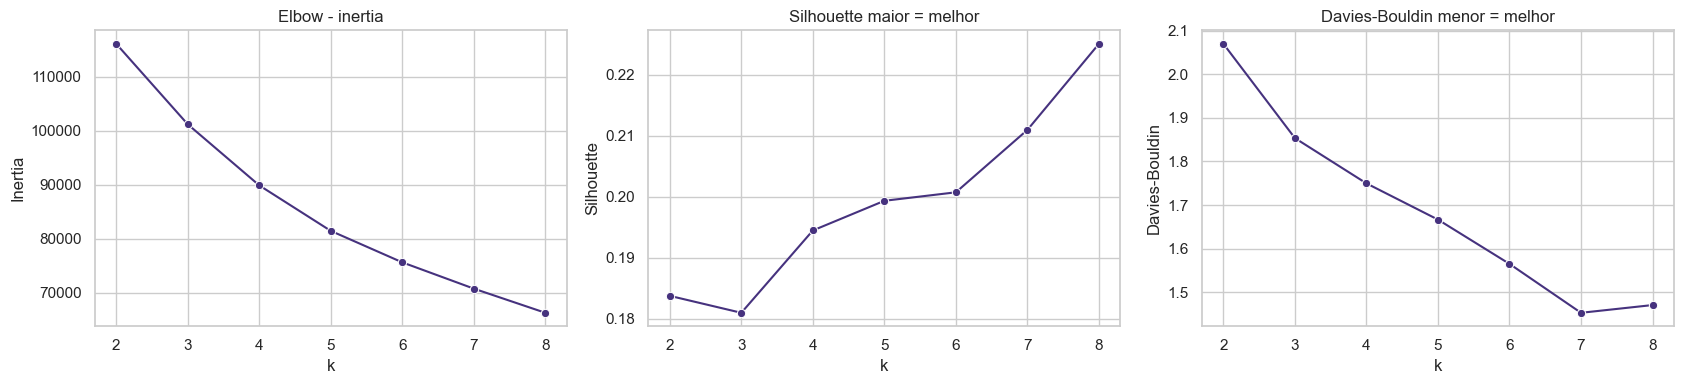

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.lineplot(data=kmeans_metrics, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('Elbow - inertia')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

sns.lineplot(data=kmeans_metrics, x='k', y='silhouette_amostra', marker='o', ax=axes[1])
axes[1].set_title('Silhouette maior = melhor')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')

sns.lineplot(data=kmeans_metrics, x='k', y='davies_bouldin', marker='o', ax=axes[2])
axes[2].set_title('Davies-Bouldin menor = melhor')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Davies-Bouldin')

plt.tight_layout()

In [7]:
best_k = int(kmeans_metrics.loc[kmeans_metrics['silhouette_amostra'].idxmax(), 'k'])
kmeans = kmeans_models[best_k]
model_df['cluster_kmeans'] = kmeans.labels_

print(f'k escolhido por silhouette: {best_k}')
model_df['cluster_kmeans'].value_counts().sort_index().to_frame('registros')

k escolhido por silhouette: 8


,registros
cluster_kmeans,
0,3238
1,1911
2,1919
3,2184
4,2330
5,2789
6,1452
7,4946


## 5. Visualizacao dos clusters K-means

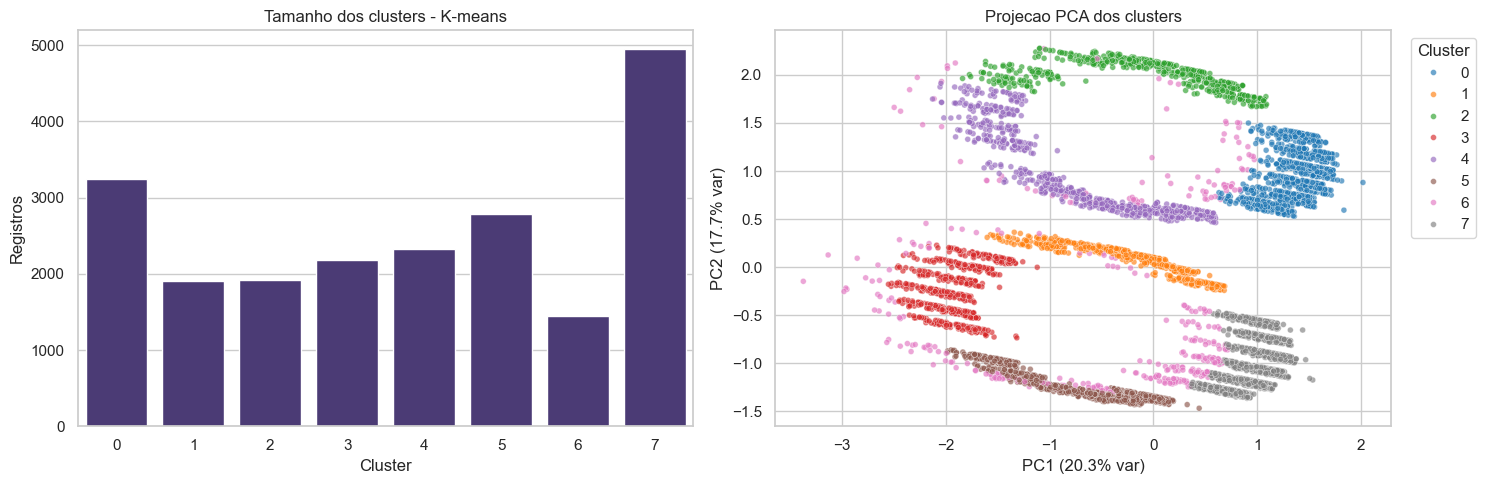

In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
plot_df = model_df[['cluster_kmeans']].copy()
plot_df['PC1'] = coords[:, 0]
plot_df['PC2'] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cluster_counts = model_df['cluster_kmeans'].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, ax=axes[0])
axes[0].set_title('Tamanho dos clusters - K-means')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Registros')

sns.scatterplot(
    data=plot_df.sample(min(6000, len(plot_df)), random_state=RANDOM_STATE),
    x='PC1', y='PC2', hue='cluster_kmeans', palette='tab10', s=18, alpha=0.65, ax=axes[1]
)
axes[1].set_title('Projecao PCA dos clusters')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)')
axes[1].legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()

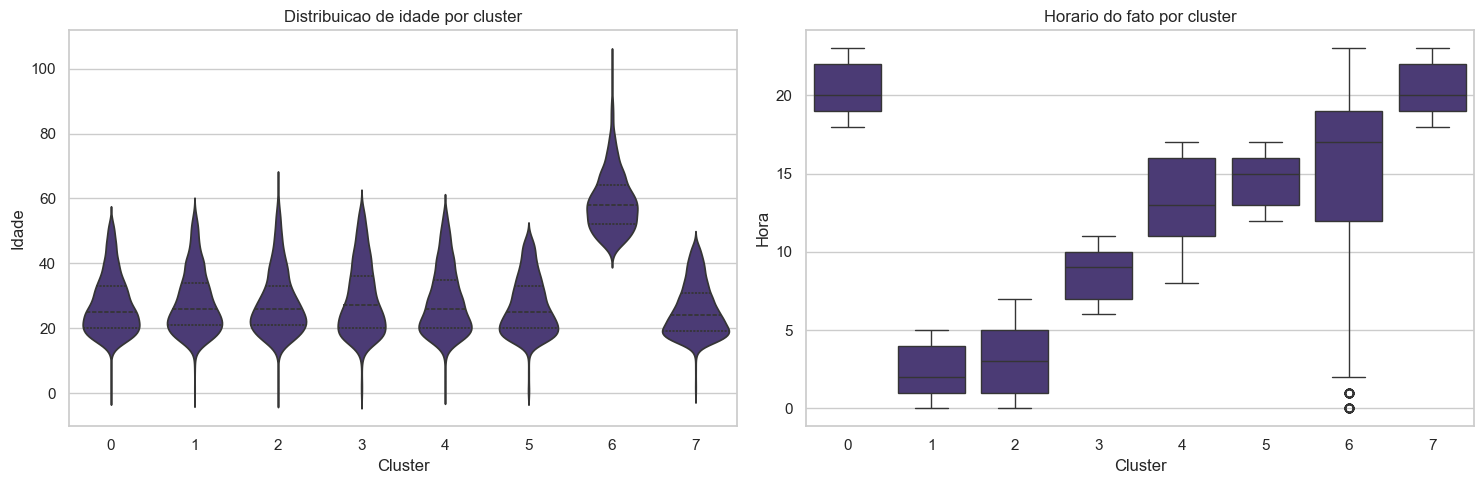

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.violinplot(data=model_df, x='cluster_kmeans', y='idade', inner='quartile', ax=axes[0])
axes[0].set_title('Distribuicao de idade por cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Idade')

sns.boxplot(data=model_df, x='cluster_kmeans', y='hora', ax=axes[1])
axes[1].set_title('Horario do fato por cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Hora')

plt.tight_layout()

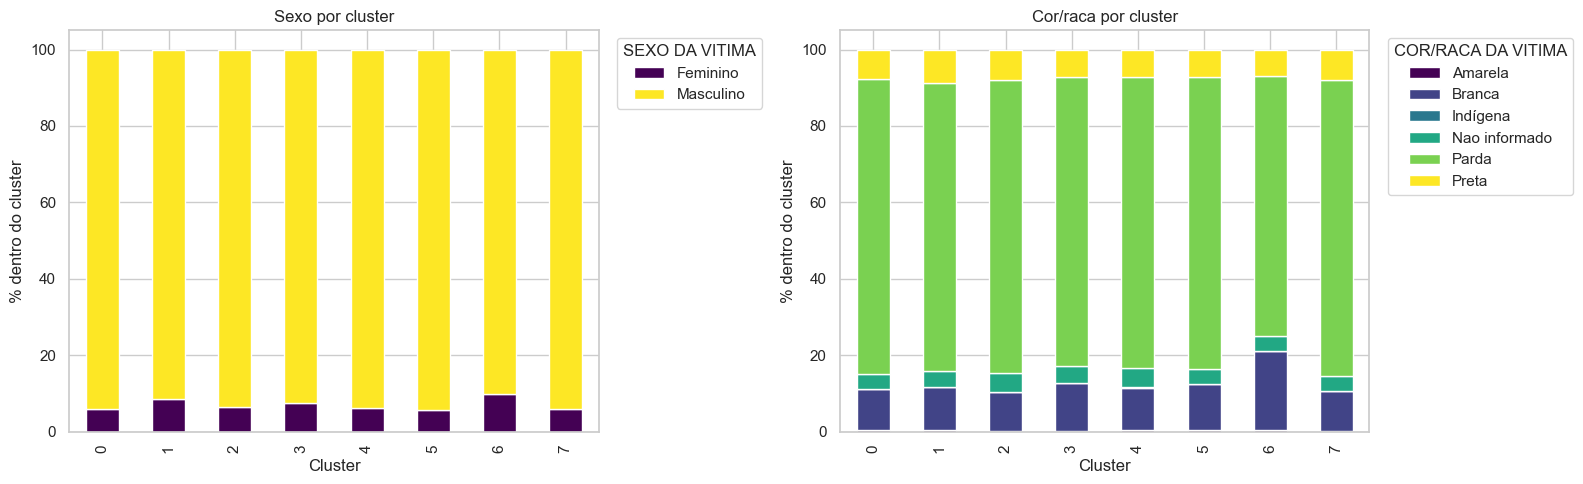

In [10]:
def stacked_percent_plot(data, index_col, col, ax, title):
    tab = pd.crosstab(data[index_col], data[col], normalize='index').mul(100)
    tab.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('% dentro do cluster')
    ax.legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
stacked_percent_plot(model_df, 'cluster_kmeans', 'SEXO DA VITIMA', axes[0], 'Sexo por cluster')
stacked_percent_plot(model_df, 'cluster_kmeans', 'COR/RACA DA VITIMA', axes[1], 'Cor/raca por cluster')
plt.tight_layout()

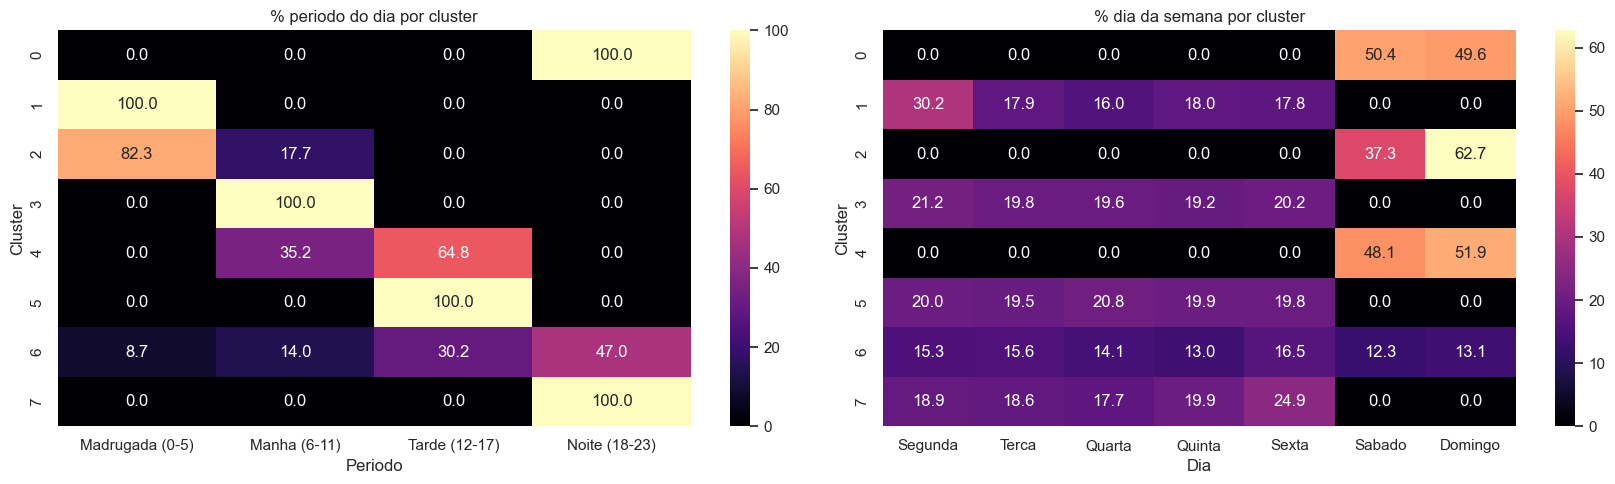

In [11]:
ordem_periodos = ['Madrugada (0-5)', 'Manha (6-11)', 'Tarde (12-17)', 'Noite (18-23)']
ordem_dias = ['Segunda', 'Terca', 'Quarta', 'Quinta', 'Sexta', 'Sabado', 'Domingo']

periodo_heat = pd.crosstab(model_df['cluster_kmeans'], model_df['periodo_dia'], normalize='index').reindex(columns=ordem_periodos).mul(100)
dia_heat = pd.crosstab(model_df['cluster_kmeans'], model_df['dia_semana'], normalize='index').reindex(columns=ordem_dias).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.heatmap(periodo_heat, annot=True, fmt='.1f', cmap='magma', ax=axes[0])
axes[0].set_title('% periodo do dia por cluster')
axes[0].set_xlabel('Periodo')
axes[0].set_ylabel('Cluster')

sns.heatmap(dia_heat, annot=True, fmt='.1f', cmap='magma', ax=axes[1])
axes[1].set_title('% dia da semana por cluster')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Cluster')

plt.tight_layout()

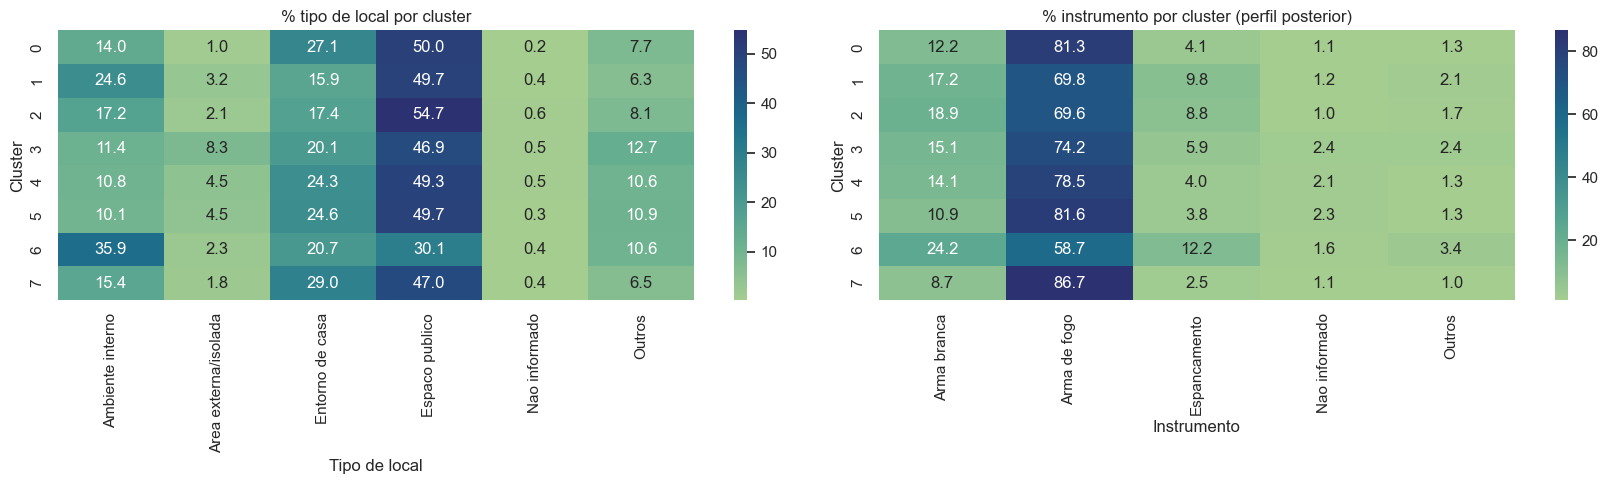

In [12]:
local_heat = pd.crosstab(model_df['cluster_kmeans'], model_df['grupo_local'], normalize='index').mul(100)
instrumento_heat = pd.crosstab(model_df['cluster_kmeans'], model_df['grupo_instrumento'], normalize='index').mul(100)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.heatmap(local_heat, annot=True, fmt='.1f', cmap='crest', ax=axes[0])
axes[0].set_title('% tipo de local por cluster')
axes[0].set_xlabel('Tipo de local')
axes[0].set_ylabel('Cluster')

sns.heatmap(instrumento_heat, annot=True, fmt='.1f', cmap='crest', ax=axes[1])
axes[1].set_title('% instrumento por cluster (perfil posterior)')
axes[1].set_xlabel('Instrumento')
axes[1].set_ylabel('Cluster')

plt.tight_layout()

## 6. Personas de risco - K-means

In [13]:
def top_pct(series, n=2):
    freq = series.value_counts(normalize=True, dropna=False).head(n).mul(100)
    return ' | '.join([f'{idx}: {val:.1f}%' for idx, val in freq.items()])

profile_rows = []
for cluster in sorted(model_df['cluster_kmeans'].unique()):
    subset = model_df[model_df['cluster_kmeans'] == cluster]
    profile_rows.append({
        'cluster': cluster,
        'n': len(subset),
        'percentual': len(subset) / len(model_df) * 100,
        'idade_media': subset['idade'].mean(),
        'idade_mediana': subset['idade'].median(),
        'faixa_etaria_top': top_pct(subset['faixa_etaria'], 2),
        'sexo_top': top_pct(subset['SEXO DA VITIMA'], 2),
        'raca_top': top_pct(subset['COR/RACA DA VITIMA'], 2),
        'periodo_top': top_pct(subset['periodo_dia'], 2),
        'dia_top': top_pct(subset['dia_semana'], 2),
        'local_top': top_pct(subset['grupo_local'], 2),
        'instrumento_top': top_pct(subset['grupo_instrumento'], 2),
    })

personas_kmeans = pd.DataFrame(profile_rows)
personas_kmeans[['percentual', 'idade_media', 'idade_mediana']] = personas_kmeans[['percentual', 'idade_media', 'idade_mediana']].round(2)
personas_kmeans['persona_sugerida'] = personas_kmeans.apply(
    lambda row: f"{row['sexo_top'].split(':')[0]} | {row['raca_top'].split(':')[0]} | {row['faixa_etaria_top'].split(':')[0]} | {row['periodo_top'].split(':')[0]}",
    axis=1,
)
display(personas_kmeans)

,cluster,n,percentual,idade_media,idade_mediana,faixa_etaria_top,sexo_top,raca_top,periodo_top,dia_top,local_top,instrumento_top,persona_sugerida
0,0,3238,15.59,27.40,25.0,18-24: 35.4% | 30-39: 23.3%,Masculino: 94.1% | Feminino: 5.9%,Parda: 77.1% | Branca: 10.8%,Noite (18-23): 100.0%,Sabado: 50.4% | Domingo: 49.6%,Espaco publico: 50.0% | Entorno de casa: 27.1%,Arma de fogo: 81.3% | Arma branca: 12.2%,Masculino | Parda | 18-24 | Noite (18-23)
1,1,1911,9.20,28.01,26.0,18-24: 34.7% | 30-39: 23.1%,Masculino: 91.4% | Feminino: 8.6%,Parda: 75.6% | Branca: 11.2%,Madrugada (0-5): 100.0%,Segunda: 30.2% | Quinta: 18.0%,Espaco publico: 49.7% | Ambiente interno: 24.6%,Arma de fogo: 69.8% | Arma branca: 17.2%,Masculino | Parda | 18-24 | Madrugada (0-5)
2,2,1919,9.24,28.03,26.0,18-24: 35.1% | 30-39: 21.5%,Masculino: 93.6% | Feminino: 6.4%,Parda: 76.7% | Branca: 10.2%,Madrugada (0-5): 82.3% | Manha (6-11): 17.7%,Domingo: 62.7% | Sabado: 37.3%,Espaco publico: 54.7% | Entorno de casa: 17.4%,Arma de fogo: 69.6% | Arma branca: 18.9%,Masculino | Parda | 18-24 | Madrugada (0-5)
3,3,2184,10.52,29.04,27.0,18-24: 30.1% | 30-39: 21.5%,Masculino: 92.6% | Feminino: 7.4%,Parda: 75.7% | Branca: 12.5%,Manha (6-11): 100.0%,Segunda: 21.2% | Sexta: 20.2%,Espaco publico: 46.9% | Entorno de casa: 20.1%,Arma de fogo: 74.2% | Arma branca: 15.1%,Masculino | Parda | 18-24 | Manha (6-11)
4,4,2330,11.22,28.45,26.0,18-24: 33.8% | 30-39: 21.8%,Masculino: 93.7% | Feminino: 6.3%,Parda: 76.1% | Branca: 11.1%,Tarde (12-17): 64.8% | Manha (6-11): 35.2%,Domingo: 51.9% | Sabado: 48.1%,Espaco publico: 49.3% | Entorno de casa: 24.3%,Arma de fogo: 78.5% | Arma branca: 14.1%,Masculino | Parda | 18-24 | Tarde (12-17)
5,5,2789,13.43,26.66,25.0,18-24: 35.8% | 30-39: 23.7%,Masculino: 94.3% | Feminino: 5.7%,Parda: 76.4% | Branca: 11.9%,Tarde (12-17): 100.0%,Quarta: 20.8% | Segunda: 20.0%,Espaco publico: 49.7% | Entorno de casa: 24.6%,Arma de fogo: 81.6% | Arma branca: 10.9%,Masculino | Parda | 18-24 | Tarde (12-17)
6,6,1452,6.99,58.99,58.0,40-59: 58.5% | 60+: 41.5%,Masculino: 90.1% | Feminino: 9.9%,Parda: 68.1% | Branca: 20.8%,Noite (18-23): 47.0% | Tarde (12-17): 30.2%,Sexta: 16.5% | Terca: 15.6%,Ambiente interno: 35.9% | Espaco publico: 30.1%,Arma de fogo: 58.7% | Arma branca: 24.2%,Masculino | Parda | 40-59 | Noite (18-23)
7,7,4946,23.81,25.54,24.0,18-24: 38.9% | 30-39: 21.2%,Masculino: 94.2% | Feminino: 5.8%,Parda: 77.5% | Branca: 10.3%,Noite (18-23): 100.0%,Sexta: 24.9% | Quinta: 19.9%,Espaco publico: 47.0% | Entorno de casa: 29.0%,Arma de fogo: 86.7% | Arma branca: 8.7%,Masculino | Parda | 18-24 | Noite (18-23)


## 7. K-medoids em amostra

K-medoids usa registros reais como centros. Como o custo cresce com matriz de distancias, usamos amostra reprodutivel.

In [14]:
def kmedoids_pam(distance_matrix, k, max_iter=25, random_state=42):
    rng = np.random.default_rng(random_state)
    n = distance_matrix.shape[0]
    medoids = rng.choice(n, size=k, replace=False)

    for _ in range(max_iter):
        labels = np.argmin(distance_matrix[:, medoids], axis=1)
        new_medoids = []

        for cluster in range(k):
            members = np.where(labels == cluster)[0]
            if len(members) == 0:
                available = np.setdiff1d(np.arange(n), np.array(new_medoids, dtype=int), assume_unique=False)
                new_medoids.append(int(rng.choice(available)))
                continue
            intra = distance_matrix[np.ix_(members, members)]
            new_medoids.append(int(members[np.argmin(intra.sum(axis=1))]))

        new_medoids = np.array(new_medoids, dtype=int)
        if np.array_equal(np.sort(medoids), np.sort(new_medoids)):
            medoids = new_medoids
            break
        medoids = new_medoids

    labels = np.argmin(distance_matrix[:, medoids], axis=1)
    inertia = distance_matrix[np.arange(n), medoids[labels]].sum()
    return labels, medoids, inertia

sample_size = min(1800, len(model_df))
rng = np.random.default_rng(RANDOM_STATE)
sample_pos = rng.choice(len(model_df), size=sample_size, replace=False)
X_sample = X[sample_pos]
sample_profile = model_df.iloc[sample_pos].copy().reset_index(drop=True)

distance_matrix = pairwise_distances(X_sample, metric='euclidean')

kmedoids_rows = []
kmedoids_results = {}
for k in k_values:
    labels, medoids, inertia = kmedoids_pam(distance_matrix, k, random_state=RANDOM_STATE + k)
    kmedoids_results[k] = (labels, medoids)
    kmedoids_rows.append({
        'k': k,
        'inertia': inertia,
        'silhouette': silhouette_score(X_sample, labels),
        'davies_bouldin': davies_bouldin_score(X_sample, labels),
    })

kmedoids_metrics = pd.DataFrame(kmedoids_rows)
display(kmedoids_metrics.round(4))

,k,inertia,silhouette,davies_bouldin
0,2,4964.1894,0.1738,2.1960
1,3,4398.0806,0.1793,1.8512
2,4,4409.7794,0.1573,2.0715
3,5,4136.2275,0.1575,1.8361
4,6,4140.8607,0.1345,2.2340
5,7,3866.0380,0.1529,2.0331
6,8,3766.5261,0.1598,1.9125


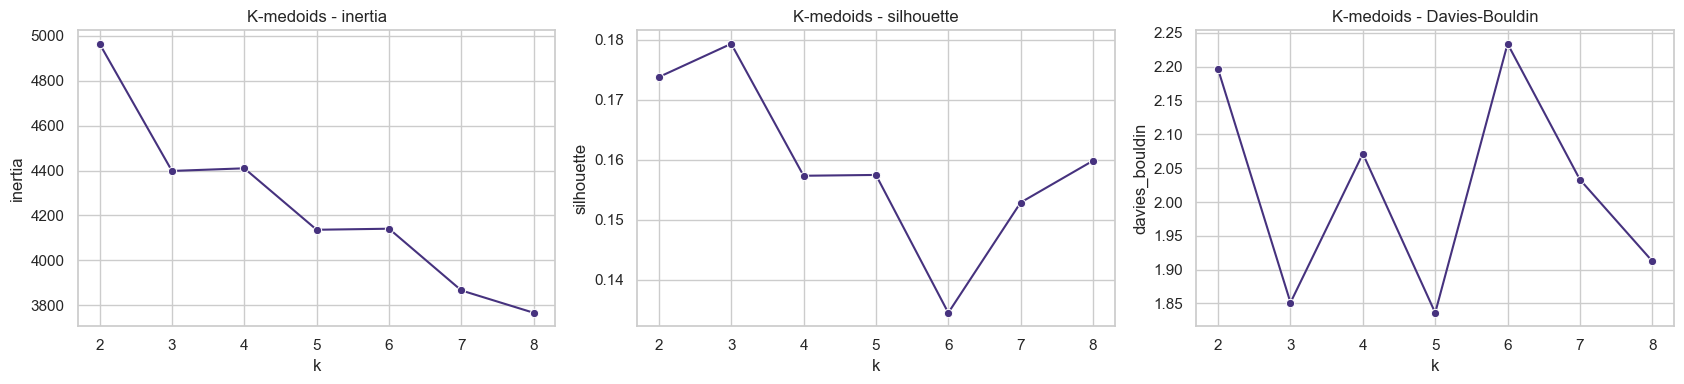

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.lineplot(data=kmedoids_metrics, x='k', y='inertia', marker='o', ax=axes[0])
axes[0].set_title('K-medoids - inertia')
axes[0].set_xlabel('k')

sns.lineplot(data=kmedoids_metrics, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('K-medoids - silhouette')
axes[1].set_xlabel('k')

sns.lineplot(data=kmedoids_metrics, x='k', y='davies_bouldin', marker='o', ax=axes[2])
axes[2].set_title('K-medoids - Davies-Bouldin')
axes[2].set_xlabel('k')

plt.tight_layout()

In [16]:
best_kmedoids = int(kmedoids_metrics.loc[kmedoids_metrics['silhouette'].idxmax(), 'k'])
labels_med, medoids = kmedoids_results[best_kmedoids]
sample_profile['cluster_kmedoids'] = labels_med

print(f'k-medoids escolhido por silhouette na amostra: {best_kmedoids}')

display_cols = [
    'idade', 'faixa_etaria', 'SEXO DA VITIMA', 'COR/RACA DA VITIMA',
    'hora', 'periodo_dia', 'dia_semana', 'grupo_local',
    'grupo_instrumento', 'SUBJETIVIDADE COMPLEMENTAR'
]
medoid_records = sample_profile.iloc[medoids][display_cols].copy()
medoid_records.insert(0, 'cluster_kmedoids', range(best_kmedoids))
display(medoid_records)

k-medoids escolhido por silhouette na amostra: 3


,cluster_kmedoids,idade,faixa_etaria,SEXO DA VITIMA,COR/RACA DA VITIMA,hora,periodo_dia,dia_semana,grupo_local,grupo_instrumento,SUBJETIVIDADE COMPLEMENTAR
1511,0,30.0,30-39,Masculino,Parda,9,Manha (6-11),Segunda,Espaco publico,Arma de fogo,Homicídio
980,1,30.0,30-39,Masculino,Parda,20,Noite (18-23),Sexta,Espaco publico,Arma de fogo,Homicídio
626,2,29.0,25-29,Masculino,Parda,21,Noite (18-23),Domingo,Espaco publico,Arma branca,Homicídio


In [17]:
medoid_rows = []
for cluster in sorted(sample_profile['cluster_kmedoids'].unique()):
    subset = sample_profile[sample_profile['cluster_kmedoids'] == cluster]
    medoid_rows.append({
        'cluster': cluster,
        'n_amostra': len(subset),
        'percentual_amostra': len(subset) / len(sample_profile) * 100,
        'idade_mediana': subset['idade'].median(),
        'faixa_etaria_top': top_pct(subset['faixa_etaria'], 2),
        'sexo_top': top_pct(subset['SEXO DA VITIMA'], 2),
        'raca_top': top_pct(subset['COR/RACA DA VITIMA'], 2),
        'periodo_top': top_pct(subset['periodo_dia'], 2),
        'local_top': top_pct(subset['grupo_local'], 2),
    })

personas_kmedoids = pd.DataFrame(medoid_rows)
personas_kmedoids[['percentual_amostra', 'idade_mediana']] = personas_kmedoids[['percentual_amostra', 'idade_mediana']].round(2)
display(personas_kmedoids)

,cluster,n_amostra,percentual_amostra,idade_mediana,faixa_etaria_top,sexo_top,raca_top,periodo_top,local_top
0,0,528,29.33,26.0,18-24: 32.2% | 30-39: 20.3%,Masculino: 94.3% | Feminino: 5.7%,Parda: 75.4% | Branca: 13.6%,Manha (6-11): 60.6% | Tarde (12-17): 23.9%,Espaco publico: 47.9% | Entorno de casa: 17.6%
1,1,704,39.11,26.0,18-24: 31.7% | 30-39: 22.0%,Masculino: 92.5% | Feminino: 7.5%,Parda: 75.6% | Branca: 13.2%,Noite (18-23): 67.2% | Tarde (12-17): 21.2%,Espaco publico: 46.4% | Entorno de casa: 24.7%
2,2,568,31.56,26.0,18-24: 33.5% | 30-39: 20.1%,Masculino: 93.1% | Feminino: 6.9%,Parda: 72.4% | Branca: 12.1%,Noite (18-23): 54.4% | Madrugada (0-5): 23.4%,Espaco publico: 50.4% | Entorno de casa: 22.7%


## 8. Leituras para decisao

Use as tabelas de personas e os graficos para escrever conclusoes no formato do projeto:

1. Percebemos que alguns clusters concentram sexo, raca, idade e horario especificos.
2. Isso sugere perfis recorrentes de vitimizacao, nao risco populacional direto.
3. Por isso, a tomada de decisao pode priorizar acoes preventivas por faixa etaria e janela de horario.
4. Como cidade/bairro foram removidos por escolha metodologica, nao concluir distribuicao regional aqui.
5. Proximo passo: validar estabilidade dos clusters e, se permitido, adicionar dados populacionais para estimar risco relativo.